In [3]:
# --- CELL 1: SETUP & FEATURE ENGINEERING ---

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# 1. VISUAL SETUP
sns.set_theme(style="whitegrid", palette="muted")

# 2. LOAD DATA
try:
    # Read the CSV file
    df = pd.read_csv('../data/my_spotify_data.csv')

    # --- FIX STARTS HERE ---
    # CRITICAL FIX: We add dayfirst=True and format='mixed'
    # This tells Pandas: "Expect dates like 13-11-2025 (Day-Month-Year)"
    df['timestamp'] = pd.to_datetime(df['timestamp'], dayfirst=True, format='mixed')
    # --- FIX ENDS HERE ---
    
    print("✅ Data loaded successfully!")

except FileNotFoundError:
    print("❌ Error: File not found. Check if 'my_spotify_data.csv' is in the '../data/' folder.")
except Exception as e:
    print(f"❌ Something went wrong: {e}")


# 3. FEATURE ENGINEERING: TIME CATEGORIES
# We define these categories based on your specific routine.
def get_time_period(hour):
    if 0 <= hour < 3:
        return "Late Night"   # 00:00 - 02:59
    elif 3 <= hour < 12:
        return "Morning"      # 03:00 - 11:59 (The Sleep Gap)
    elif 12 <= hour < 17:
        return "Afternoon"    # 12:00 - 16:59
    elif 17 <= hour < 21:
        return "Evening"      # 17:00 - 20:59
    else:
        return "Night"        # 21:00 - 23:59

# Apply the function to create the 'time_period' column
# We use the .dt accessor to get the hour from the timestamp directly
df['hour'] = df['timestamp'].dt.hour
df['time_period'] = df['hour'].apply(get_time_period)


# 4. FEATURE ENGINEERING: THE HEARTBREAK FLAG
# Define the specific week of the breakup
start_date = pd.Timestamp("2026-01-19")
end_date = pd.Timestamp("2026-01-26")

# Create a True/False column for easy filtering later
df['is_heartbreak_week'] = (df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)

# 5. VERIFY
print(f"Total Rows: {len(df)}")
print("First 5 rows with new columns:")
display(df.head(5))

✅ Data loaded successfully!
Total Rows: 1051
First 5 rows with new columns:


,timestamp,song_name,artist,valence,energy,hour,time_period,is_heartbreak_week
0,2025-11-01 00:03:00,Barbaad,The Rish,0.28,0.51,0,Late Night,False
1,2025-11-01 00:07:00,Hurts So Good,Astrid S,0.38,0.61,0,Late Night,False
2,2025-11-01 00:14:00,Brooklyn Baby,Lana Del Rey,0.09,0.66,0,Late Night,False
3,2025-11-01 02:25:00,supenatural,Ariana Grande,0.52,0.71,2,Late Night,False
4,2025-11-01 02:30:00,Hurts So Good,Astrid S,0.38,0.61,2,Late Night,False


Heartbreak Impact Report:
Average Happiness during Normal Time: 0.46
Average Hapiness during Heartbreak Time: 0.26
Happiness dropped by 42.7% during this week.


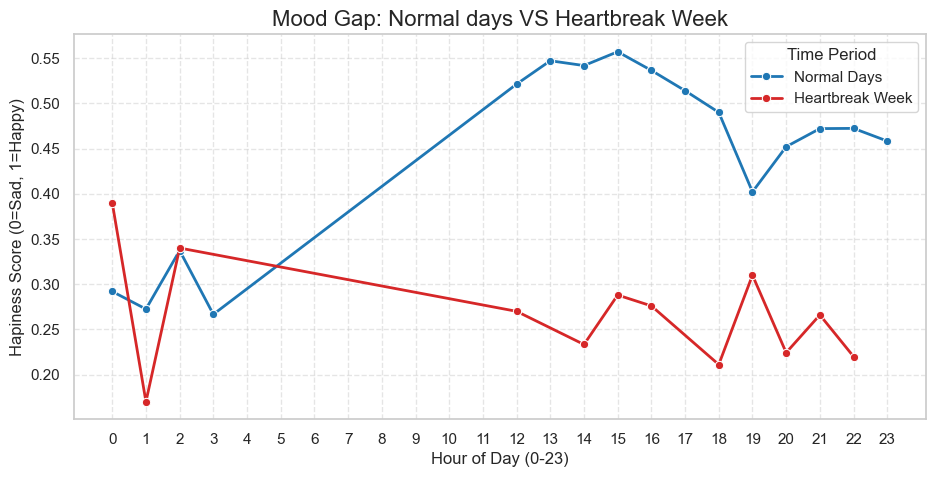

In [4]:
# --- CELL 2: THE HEARTBREAK REPORT (EDA) ---

# 1. SEPARATE THE DATA
# We need to split my history into two distinct sets: "Heartbreak Mode" and "Normal Life"
# so we can compare them side-by-side.
heartbreak_df = df[df['is_heartbreak_week'] == True]
normal_df = df[df['is_heartbreak_week'] == False]

# 2. CALCULATE THE MEAN (THE MATH)
# Let's get the exact numbers. How low did the happiness actually dip?
avg_heartbreak_valence = heartbreak_df['valence'].mean()
avg_normal_valence = normal_df['valence'].mean()

# Calculate the percentage drop to measure the "Crash"
percent_drop = ((avg_normal_valence - avg_heartbreak_valence) / avg_normal_valence) * 100

# 3. PRINT THE STATS
print("Heartbreak Impact Report:")
print(f"Average Happiness during Normal Time: {avg_normal_valence:.2f}")
print(f"Average Hapiness during Heartbreak Time: {avg_heartbreak_valence:.2f}")
print(f"Happiness dropped by {percent_drop:.1f}% during this week.")

# 4. VISUALIZE THE "MOOD GAP"
# We'll use a clean line chart to show the physical gap between the two timelines.
plt.figure(figsize=(11,5))

sns.lineplot(
    data=df,
    x='hour',
    y='valence',
    hue='is_heartbreak_week',               # This automatically splits the lines into True vs False
    palette={False: 'tab:blue', True: 'tab:red'}, # Blue for Normal, Red for Heartbreak
    marker='o',                             # Adds dots so we can see the exact hourly data points
    linewidth=2,                            # Thicker lines for better visibility
    errorbar=None                           # Removes the messy shaded confidence intervals for a clean look
)

# Styling the chart to look professional
plt.title("Mood Gap: Normal days VS Heartbreak Week", fontsize=16)
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Hapiness Score (0=Sad, 1=Happy)")

# Rename the legend labels instead of "True" and "False" so they make sense to a human 
plt.legend(title="Time Period", labels=["Normal Days", "Heartbreak Week"])

# Force the X-axis to show every single hour (0, 1, 2... 23)
plt.xticks(range(0,24))

# Add a faint grid behind the lines so it's easier to read the values
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Testing cluster counts.....


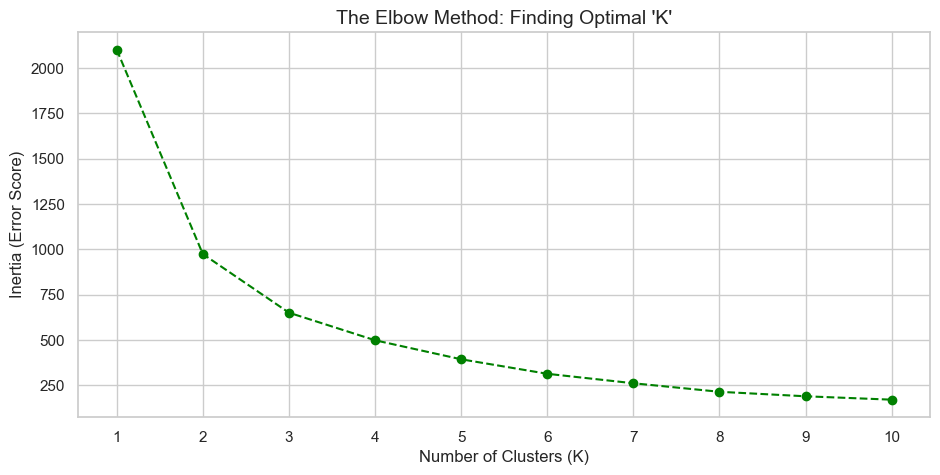

In [5]:
# --- CELL 3: FINDING THE OPTIMAL CLUSTERS (THE ELBOW METHOD) ---

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. SILENCE THE WARNINGS
# Windows sometimes complains about "Memory Leaks" with this specific AI library.
# It's a harmless bug, but the red text is ugly, so we tell Python to ignore it.
import warnings
warnings.filterwarnings('ignore')
import os
os.environ["OMP_NUM_THREADS"] = "1"

# 2. PREPARE THE DATA
# The AI is just a math machine; it can't read song titles.
# We feed it 'Valence' and 'Energy' so it can find patterns in the numbers.
features = df[['valence', 'energy']]

# 3. SCALE THE DATA (CRITICAL STEP)
# This converts our data into a standard format so the AI treats both features equally.
# It prevents the AI from favoring one just because the numbers look "bigger" or "smaller."
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# 4. THE EXPERIMENT (TESTING 1 TO 10 CLUSTERS)
# We don't know if I have 2 moods or 10 moods. So let's test ALL of them.
inertia = []
K_range = range(1,11)

print("Testing cluster counts.....")

for k in K_range:
    # "Hey AI, try organizing my songs into 'k' piles."
    kmeans= KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # Train the model on our scaled data
    kmeans.fit(scaled_features)
    
    # "Inertia" is the Messiness Score. We record it to see how tidy this specific number of piles is.
    inertia.append(kmeans.inertia_)

# 5. VISUALIZE THE RESULTS
# We draw a line chart. We are looking for the "Elbow"—the spot where the line bends
# and stops dropping steeply. That bend is our magic number.
plt.figure(figsize=(11,5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='green')

plt.title("The Elbow Method: Finding Optimal 'K'", fontsize=14)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Error Score)")
plt.xticks(K_range) # Force the chart to show numbers 1 through 10
plt.grid(True)

plt.show()

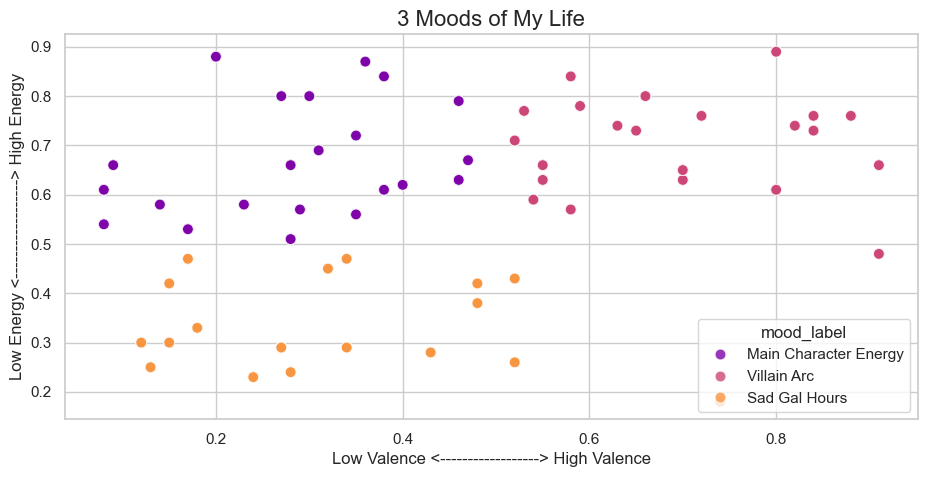

The 3 listening personas are.....

 Sad Gal Hours (326 plays): 
    - Average Happiness: 0.32
    - Average Energy: 0.34
    - Top Artists are: Billie Eilish, IU, Lana Del Rey

 Main Character Energy (324 plays): 
    - Average Happiness: 0.27
    - Average Energy: 0.65
    - Top Artists are: Chase Atlantic, BTS, Taylor Swift

 Villain Arc (401 plays): 
    - Average Happiness: 0.69
    - Average Energy: 0.70
    - Top Artists are: Kendrick Lamar, Meghan Trainor, Jennie


In [6]:
# --- CELL 4: CLUSTERING & PROFILING ---

# 1. APPLY THE AI
# We previously found that 3 was the perfect number of "Moods" (clusters).
# Now we initialize the K-Means algorithm to look for exactly 3 groups.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

# The AI analyzes every song's Valence and Energy, decides which group it belongs to,
# and stamps a label (0, 1, or 2) onto it.
df['cluster'] = kmeans.fit_predict(scaled_features)

# 2. RENAME THE CLUSTERS (HUMANIZE THEM)
# We map the robot numbers to specific mood names.
mood_names = {
    0: 'Sad Gal Hours',         # Low Valence, Low Energy
    1: 'Main Character Energy', # High Valence, High Energy
    2: 'Villain Arc'            # Low Valence, High Energy (Angst/Intense)
}

df['mood_label'] = df['cluster'].map(mood_names)

# 3. VISUALIZE THE AURA
# Let's draw the map of my music taste.
plt.figure(figsize=(11,5))

# We plot Happiness (X) vs. Energy (Y) and color the dots by their new Cluster ID.
sns.scatterplot(
    data=df,
    x='valence',
    y='energy',
    hue='mood_label',
    palette='plasma',   # A nice professional color scheme
    s=60,                # Size of the dots
    alpha=0.8            # Slight transparency in case dots overlap
)

# Adding the specific labels so the chart is easy to read
plt.title("3 Moods of My Life", fontsize=16)
plt.xlabel("Low Valence <------------------> High Valence")
plt.ylabel("Low Energy <------------------> High Energy")
plt.show()

# 3. PROFILE THE PERSONAS
# The chart is pretty, but we need to know what "Cluster 0" actually IS.
# Is it the Sad pile? The Party pile? Let's check the stats.
print("The 3 listening personas are.....")

for i in range(3):
    # Filter the dataframe to see ONLY the songs in this specific group
    cluster_data = df[df['cluster'] == i]
    mood_name = mood_names[i]
    
    # Calculate the average mood for this group
    avg_val = cluster_data['valence'].mean()
    avg_eng = cluster_data['energy'].mean()
    size = len(cluster_data)

    # Find out which artists define this mood
    top_artists = cluster_data['artist'].value_counts().head(3).index.tolist()

    print(f"\n {mood_name} ({size} plays): ")
    print(f"    - Average Happiness: {avg_val:.2f}")
    print(f"    - Average Energy: {avg_eng:.2f}")
    print(f"    - Top Artists are: {', '.join(top_artists)}")

In [7]:
# --- CELL 5: TRAINING THE "MOODY DJ" (PREDICTION MODEL) ---

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. DEFINE THE PROBLEM
# X = The "Questions" (How happy is this song? How energetic?)
# y = The "Answer" (Which cluster does it belong to?)
X = df[['valence','energy']]
y = df['cluster']

# 2. SPLIT THE DATA (STUDY vs. EXAM)
# We don't want the AI to just memorize the answers.
# We hold back 20% of the data (test_size=0.2) to use as a final "Exam" later.
# The AI only gets to see the other 80% (X_train) to learn from.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. INITIALIZE THE BRAIN
# We create a Random Forest—which is basically 100 tiny decision trees working together
# to vote on the best answer.
moody_dj = RandomForestClassifier(n_estimators=100, random_state=42)

# 4. TRAIN THE MODEL
# This is the learning step. The AI looks at the training data and finds the patterns.
moody_dj.fit(X_train, y_train)

# 5. TEST THE MODEL
# Now we give it the "Exam" questions (X_test) that it has never seen before
# and ask it to guess the answers.
y_pred = moody_dj.predict(X_test)

# 6. GRADE THE PERFORMANCE
# We compare the AI's guesses (y_pred) to the real answers (y_test).
accuracy = accuracy_score(y_test, y_pred) * 100

print(f"AI Model Accuracy: {accuracy:.2f}%")
print("Classification Report")
print(classification_report(y_test, y_pred))


AI Model Accuracy: 100.00%
Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        69
           1       1.00      1.00      1.00        54
           2       1.00      1.00      1.00        88

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211



In [8]:
# --- CELL 6: SAVING THE MODELS (FREEZING THE BRAIN) ---

import joblib
import os

# 1. CREATE A FOLDER FOR MODELS
# We don't want to clutter your main folder, so we make a specific 'models' directory.
# exist_ok=True means "Don't crash if the folder already exists."
os.makedirs('../models', exist_ok=True)

# 2. SAVE THE DATA
# We save the updated dataframe (which now has the 'cluster' labels) to a new CSV.
# This way, the website can load the pre-labeled songs instantly.
df.to_csv('../data/spotify_data_clustered.csv', index=False)

# 3. SAVE THE BRAINS (PICKLING)
# We take the trained AI models and "freeze" them into .pkl files.
# The website will "unfreeze" them later to make predictions.

# Save the Moody DJ (The Random Forest Predictor)
joblib.dump(moody_dj, '../models/moody_dj.pkl')

# CRITICAL: Save the Scaler
# If we don't save this, the website won't know how to translate
# "Happy=0.8" into the specific math language the AI learned.
joblib.dump(scaler, '../models/scaler.pkl')

# Save the K-Means model (Just in case we need the cluster centers later)
joblib.dump(kmeans, '../models/kmeans.pkl')

print("Success! Data and Models are saved.")
print(" - CSV saved to: data/spotify_data_clustered.csv")
print(" - Models saved to: models/ folder")

Success! Data and Models are saved.
 - CSV saved to: data/spotify_data_clustered.csv
 - Models saved to: models/ folder
